In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

print("Libraries loaded successfully")

Libraries loaded successfully


In [5]:
df = pd.read_csv("dataset.csv")
print("first 5 rows of the dataset:")
df.head()

first 5 rows of the dataset:


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [6]:
print("shape", df.shape)

print("columns", df.columns)

df.info()
df.describe()
print("missing values", df.isnull().sum())


shape (2640, 12)
columns Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type         

In [7]:
#data preprocessing
 #remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

Removed 0 duplicate rows


In [48]:
#fill missing numbers with median values
number_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
               'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

for col in number_cols:
    df[col] = df[col].fillna(df[col].median())
    
print("missing vaues filled")
print(df.isnull().sum())

missing vaues filled
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
Date                    0
Quarter                 0
Month_sin               0
Month_cos               0
Lag_1                   0
Lag_3                   0
Rolling_3               0
Delivery_Rate           0
Price_per_kWh           0
dtype: int64


In [9]:
df['Date'] = pd.to_datetime({'year': df['Year'], 'month': df['Month'], 'day': 1})

# Sort from oldest to newest
df = df.sort_values('Date').reset_index(drop=True)

print("Date column created!")
print(df[['Year', 'Month', 'Date']].head())

Date column created!
   Year  Month       Date
0  2015      1 2015-01-01
1  2015      1 2015-01-01
2  2015      1 2015-01-01
3  2015      1 2015-01-01
4  2015      1 2015-01-01


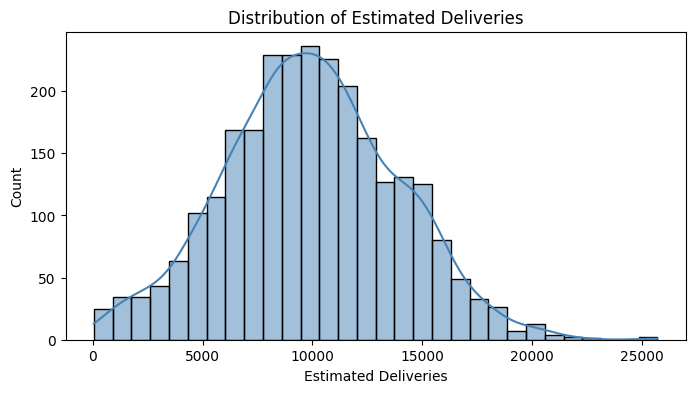

In [10]:
# Chart 1: Distribution of Estimated Deliveries

plt.figure(figsize=(8, 4))
sns.histplot(df['Estimated_Deliveries'], bins=30, color='steelblue', kde=True)
plt.title('Distribution of Estimated Deliveries')
plt.xlabel('Estimated Deliveries')
plt.ylabel('Count')
plt.show()

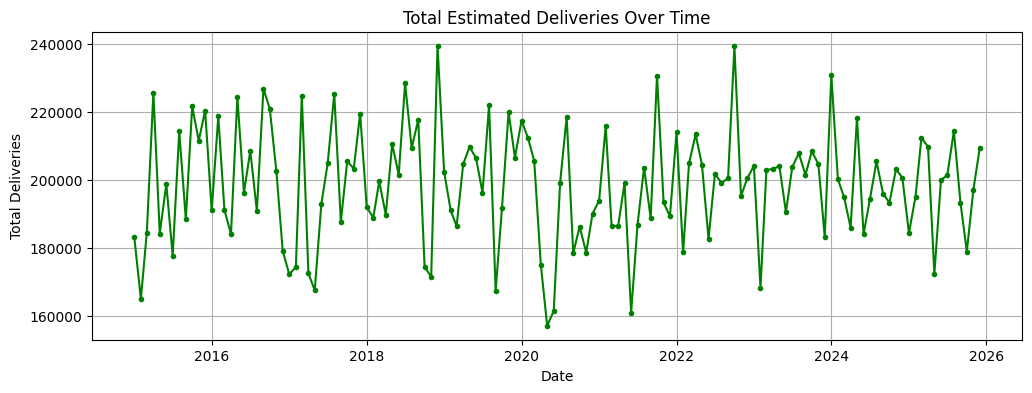

In [11]:
# Chart 2: Total Deliveries Over Time

monthly = df.groupby('Date')['Estimated_Deliveries'].sum()

plt.figure(figsize=(12, 4))
plt.plot(monthly.index, monthly.values, color='green', marker='o', markersize=3)
plt.title('Total Estimated Deliveries Over Time')
plt.xlabel('Date')
plt.ylabel('Total Deliveries')
plt.grid(True)
plt.show()

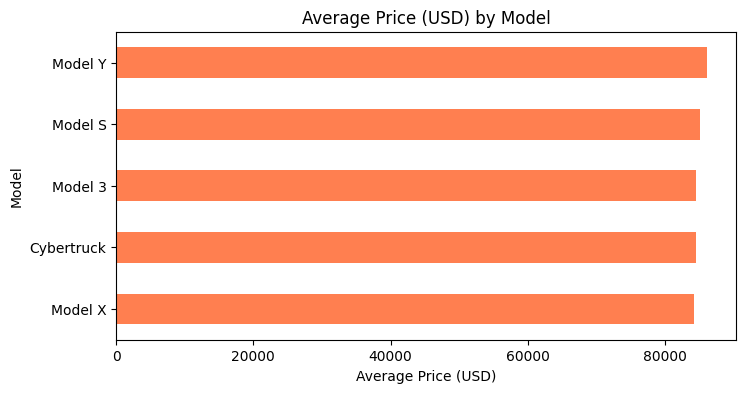

In [12]:
# Chart 3: Average Price by Model
plt.figure(figsize=(8, 4))
df.groupby('Model')['Avg_Price_USD'].mean().sort_values().plot(kind='barh', color='coral')
plt.title('Average Price (USD) by Model')
plt.xlabel('Average Price (USD)')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_42992\1022556622.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y='Estimated_Deliveries', data=df, palette='Set2')


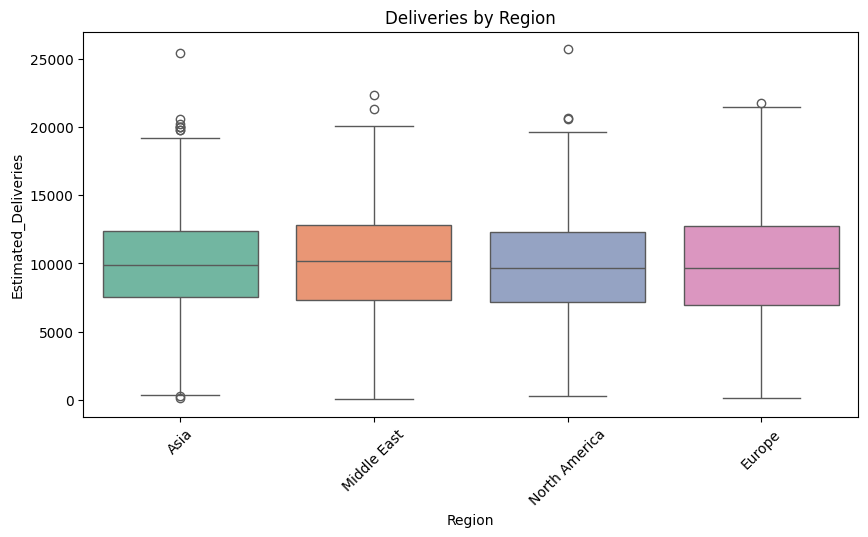

In [13]:
# Chart 4: (Boxplot)

plt.figure(figsize=(10, 5))
sns.boxplot(x='Region', y='Estimated_Deliveries', data=df, palette='Set2')
plt.title('Deliveries by Region')
plt.xticks(rotation=45)
plt.show()

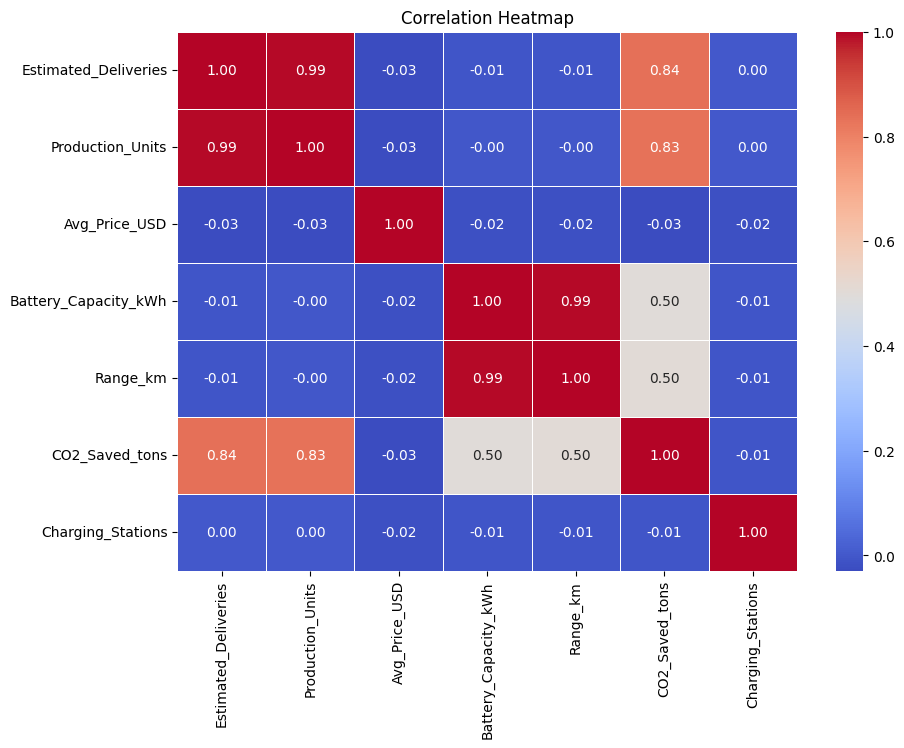

In [14]:
# Chart 5: Correlation Heatmap
#close to 1 = strong positive relationship
# close to -1 = strong negative relationship
plt.figure(figsize=(10, 7))
sns.heatmap(df[number_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [15]:

df['Quarter'] = df['Date'].dt.quarter

# Cyclical month encoding
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

print("Time features created!")

Time features created!


In [16]:

# This helps the model learn from the past
df['Lag_1'] = df['Estimated_Deliveries'].shift(1)   # 1 month ago
df['Lag_3'] = df['Estimated_Deliveries'].shift(3)   # 3 month ago

# Rolling Average — average of last 3 months
df['Rolling_3'] = df['Estimated_Deliveries'].rolling(window=3).mean()

print("Lag and Rolling features created!")

Lag and Rolling features created!


In [17]:
# Ratio Features
# What % of produced cars were actually delivered?
df['Delivery_Rate'] = df['Estimated_Deliveries'] / (df['Production_Units'] + 1)

# How much does each kWh of battery cost?
df['Price_per_kWh'] = df['Avg_Price_USD'] / (df['Battery_Capacity_kWh'] + 1)

print("Ratio features created!")

Ratio features created!


In [18]:
# Drop rows with NaN values that came from lag/rolling features
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print("Rows with NaN removed. Remaining rows:", len(df))

Rows with NaN removed. Remaining rows: 2637


In [19]:
print(df.columns.tolist())

['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations', 'Date', 'Quarter', 'Month_sin', 'Month_cos', 'Lag_1', 'Lag_3', 'Rolling_3', 'Delivery_Rate', 'Price_per_kWh']


In [20]:
# Define which columns go into the model (X = input, y = what we predict)
features = [
  'Year',
    'Quarter',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km'

]

X = df[features]                  
y = df['Estimated_Deliveries']      

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2637, 6)
y shape: (2637,)


In [21]:
# Split into Training (80%) and Testing (20%) sets
# Model trains on train data and is tested on unseen test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    
    random_state=42    
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 2109
Testing samples : 528


In [22]:
# We tune Random Forest to find the best settings

print("Tuning Random Forest... please wait...")

param_grid = {
    'n_estimators' : [50, 100, 200],    # how many trees to build
    'max_depth'    : [3, 5, 10, None],  # how deep each tree grows 
    'min_samples_split' : [2, 5, 10]    
}

grid_search = GridSearchCV(
    estimator  = RandomForestRegressor(random_state=42),
    param_grid = param_grid,
    cv         = 3,                     # 3-fold cross validation (faster than 5)
    scoring    = 'neg_root_mean_squared_error',
    n_jobs     = -1,                    # use all CPU cores to go faster
    verbose    = 1                      # shows progress while running
)

grid_search.fit(X_train, y_train)
print("\nBest Parameters:", grid_search.best_params_)

Tuning Random Forest... please wait...


Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}


In [24]:
# Evaluate the tuned Random Forest model
from sklearn.metrics import mean_squared_error


best_model = grid_search.best_estimator_
best_preds = best_model.predict(X_test)

print("Tuned Random Forest Results:")
print("RMSE     :", round(np.sqrt(mean_squared_error(y_test, best_preds)), 2))
print("MAE      :", round(mean_absolute_error(y_test, best_preds), 2))
print("R2 Score :", round(r2_score(y_test, best_preds), 4))

Tuned Random Forest Results:
RMSE     : 424.1
MAE      : 342.51
R2 Score : 0.9877


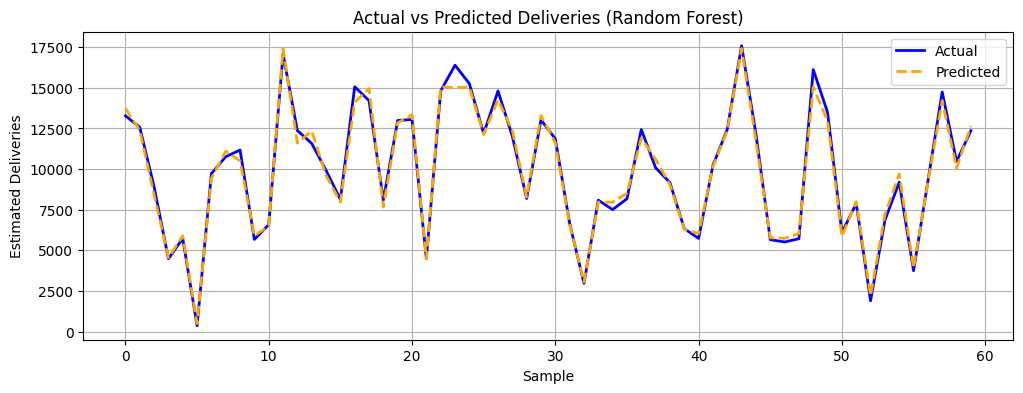

In [25]:
# Actual vs Predicted plot
plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:60], label='Actual',    color='blue',   linewidth=2)
plt.plot(best_preds[:60],    label='Predicted', color='orange', linewidth=2, linestyle='--')
plt.title('Actual vs Predicted Deliveries (Random Forest)')
plt.xlabel('Sample')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.grid(True)
plt.show()

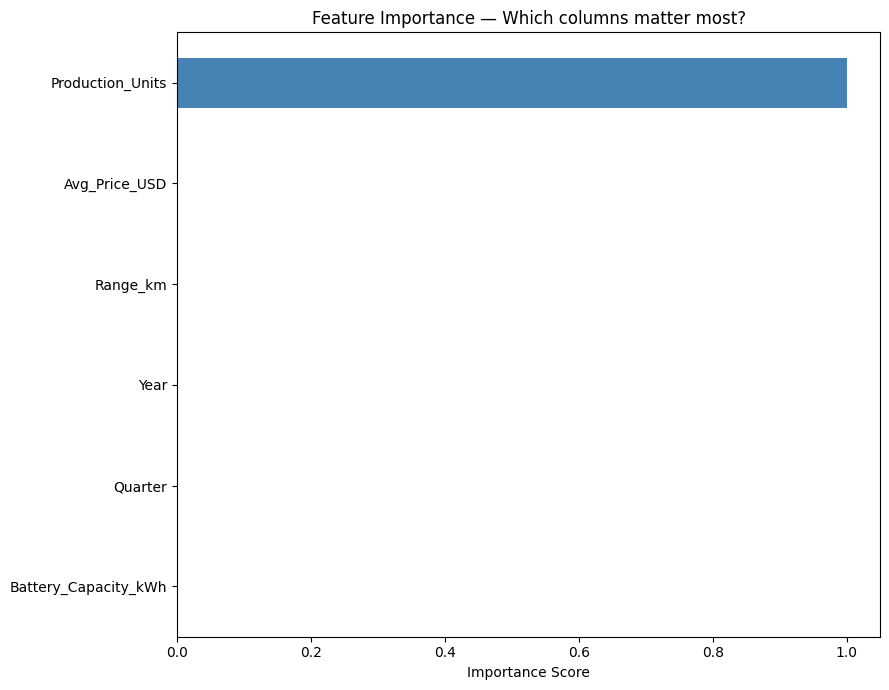

In [26]:
# Feature which columns helped the model most?
feat_imp = pd.Series(best_model.feature_importances_, index=features)
feat_imp.sort_values().plot(kind='barh', figsize=(9, 7), color='steelblue')
plt.title('Feature Importance — Which columns matter most?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [41]:
# Import Prophet
from prophet import Prophet

# Prophet needs columns named exactly 'ds' (date) and 'y' (value)
monthly_ts = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()
monthly_ts.columns = ['ds', 'y']   # rename columns

print("Data ready for Prophet:")
print(monthly_ts.tail())

Data ready for Prophet:
            ds       y
127 2025-08-01  214357
128 2025-09-01  193337
129 2025-10-01  178964
130 2025-11-01  197146
131 2025-12-01  209391


In [ ]:
#  train the Prophet model
model = Prophet()
model.fit(monthly_ts)

print("Model trained successfully!")

17:37:52 - cmdstanpy - INFO - Chain [1] start processing
17:37:52 - cmdstanpy - INFO - Chain [1] done processing


Model trained successfully!


In [43]:
# Create next 12 months to forecast into
future = model.make_future_dataframe(periods=12, freq='MS')  # MS = Month Start

print("Future dates created:")
print(future.tail(15))

Future dates created:
            ds
129 2025-10-01
130 2025-11-01
131 2025-12-01
132 2026-01-01
133 2026-02-01
134 2026-03-01
135 2026-04-01
136 2026-05-01
137 2026-06-01
138 2026-07-01
139 2026-08-01
140 2026-09-01
141 2026-10-01
142 2026-11-01
143 2026-12-01


In [ ]:
# Predict deliveries for those future months
forecast = model.predict(future)

# Show important columns only
print("Forecast results:")
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)# yhat       = predicted value
# yhat_lower = lowest possible value
# yhat_upper = highest possible value


Forecast results:


,ds,yhat,yhat_lower,yhat_upper
132,2026-01-01,195453.060501,175559.253881,215889.940183
133,2026-02-01,192273.789724,172428.012482,214481.506318
134,2026-03-01,198172.559464,177963.586928,218961.029378
135,2026-04-01,196851.913556,175560.987764,216840.429700
136,2026-05-01,195741.682108,174497.446904,215000.304964
137,2026-06-01,189872.996708,170051.711215,211227.279200
138,2026-07-01,200142.745340,179757.759134,221266.950352
139,2026-08-01,210571.121776,190269.608953,230437.592556
140,2026-09-01,194574.655288,175082.264519,215419.549448
141,2026-10-01,205052.814799,184742.578779,226547.369002


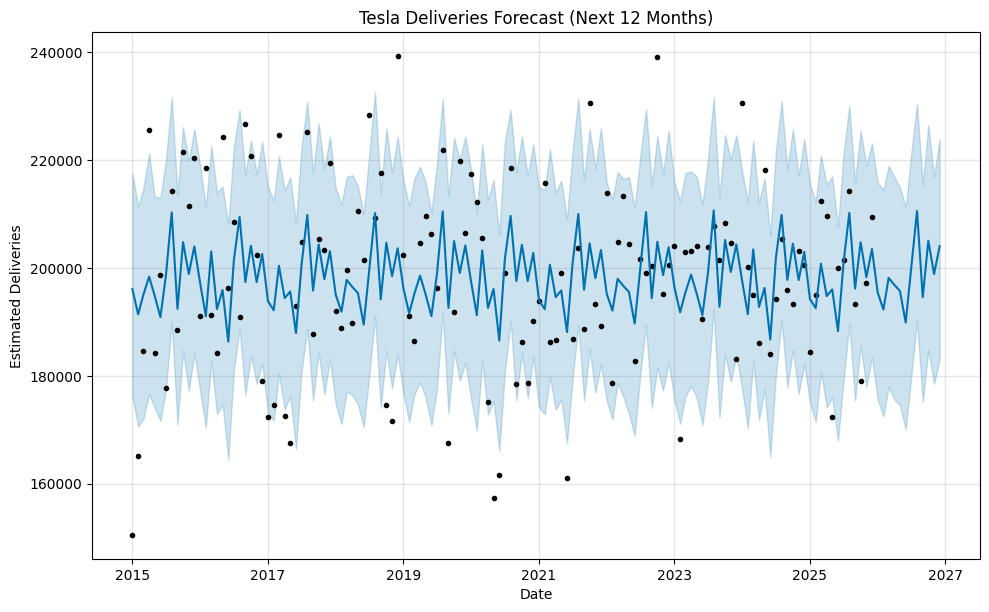

In [46]:
# Plot the forecast — Prophet makes this super easy!
fig = model.plot(forecast)
plt.title('Tesla Deliveries Forecast (Next 12 Months)')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.show()

yhat        → the predicted number of deliveries  
yhat_lower  → worst case (minimum expected)  
yhat_upper  → best case (maximum expected)

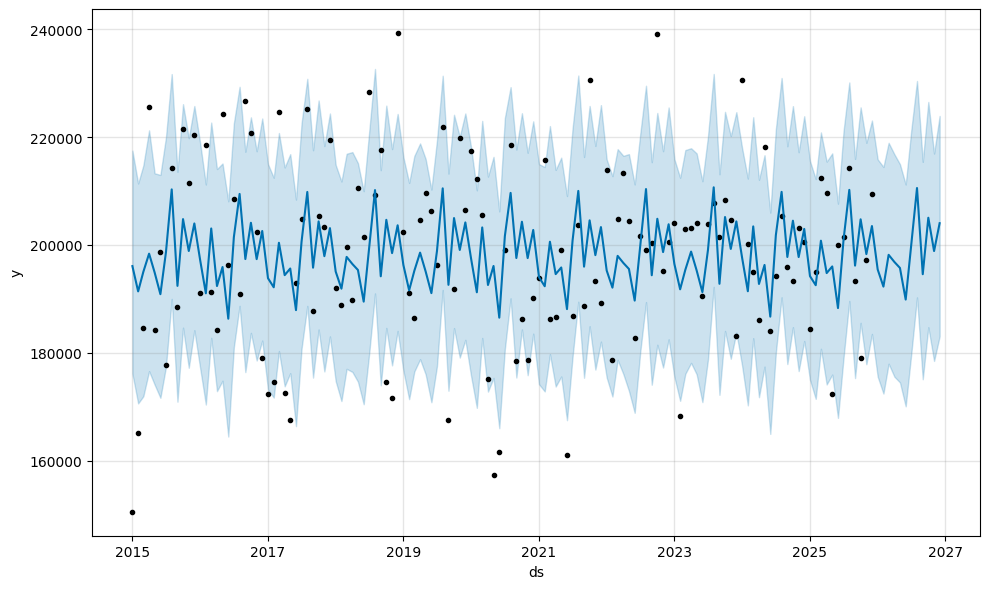

In [47]:
model.plot(forecast)
plt.show()